In [63]:
import pandas as pd
df = pd.read_csv("../data/students.csv")
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [64]:
df.shape

(2392, 15)

In [65]:
df.info

<bound method DataFrame.info of       StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0          1001   17       1          0                  2        19.833723   
1          1002   18       0          0                  1        15.408756   
2          1003   15       0          2                  3         4.210570   
3          1004   17       1          0                  3        10.028829   
4          1005   17       1          0                  2         4.672495   
...         ...  ...     ...        ...                ...              ...   
2387       3388   18       1          0                  3        10.680555   
2388       3389   17       0          0                  1         7.583217   
2389       3390   16       1          0                  2         6.805500   
2390       3391   16       1          1                  0        12.416653   
2391       3392   16       1          0                  2        17.819907   

      Absences  Tut

In [66]:
df.describe

<bound method NDFrame.describe of       StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0          1001   17       1          0                  2        19.833723   
1          1002   18       0          0                  1        15.408756   
2          1003   15       0          2                  3         4.210570   
3          1004   17       1          0                  3        10.028829   
4          1005   17       1          0                  2         4.672495   
...         ...  ...     ...        ...                ...              ...   
2387       3388   18       1          0                  3        10.680555   
2388       3389   17       0          0                  1         7.583217   
2389       3390   16       1          0                  2         6.805500   
2390       3391   16       1          1                  0        12.416653   
2391       3392   16       1          0                  2        17.819907   

      Absences  T

In [67]:
df.dtypes

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object

Numeric Data columns:
age
studytimeweekly
absences
gpa
categorical Data Columns:
gender
ethnicity
parenteducation
parentalsupport
gradeclass
Binary Columns:
sports
music
volunteering
tutoring
Identifier:
studentid

In [68]:
df.isnull().sum()

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [69]:
df.columns = df.columns.str.lower().str.strip()
df.columns

Index(['studentid', 'age', 'gender', 'ethnicity', 'parentaleducation',
       'studytimeweekly', 'absences', 'tutoring', 'parentalsupport',
       'extracurricular', 'sports', 'music', 'volunteering', 'gpa',
       'gradeclass'],
      dtype='object')

In [70]:
df['gpa'].min(),df['gpa'].max

(0.0,
 <bound method Series.max of 0       2.929196
 1       3.042915
 2       0.112602
 3       2.054218
 4       1.288061
           ...   
 2387    3.455509
 2388    3.279150
 2389    1.142333
 2390    1.803297
 2391    2.140014
 Name: gpa, Length: 2392, dtype: float64>)

In [71]:
df['absences'].describe()

count    2392.000000
mean       14.541388
std         8.467417
min         0.000000
25%         7.000000
50%        15.000000
75%        22.000000
max        29.000000
Name: absences, dtype: float64

In [72]:
df['gpa'].mean()

1.9061863027265407

In [73]:
mean_gpa_tutoring = df.groupby('tutoring')['gpa'].mean()
mean_gpa_tutoring

tutoring
0    1.818968
1    2.108325
Name: gpa, dtype: float64

In [74]:
df.groupby('parentalsupport')['gpa'].mean()

parentalsupport
0    1.540128
1    1.755700
2    1.884246
3    2.042409
4    2.191545
Name: gpa, dtype: float64

In [75]:
df.groupby('tutoring')['gpa'].mean().diff()

tutoring
0         NaN
1    0.289357
Name: gpa, dtype: float64

Impact of Tutoring:
Students recieving tutoring show an average GPA increase of 0.29 points compared to those without tutoring, indicating a positive association between tutoring support and academic performance.

In [76]:
mean_gpa = df.groupby('parentalsupport')['gpa'].mean()
mean_gpa[4] - mean_gpa[0]

0.6514170476971055

**Parental support shows a stronger association with GPA than tutoring.**
While tutoring is linked to an average GPA increase of ~0.29 points, students with the highest level of parental support exhibit an overall GPA increase of approximately 0.65 points compared to those with no support.

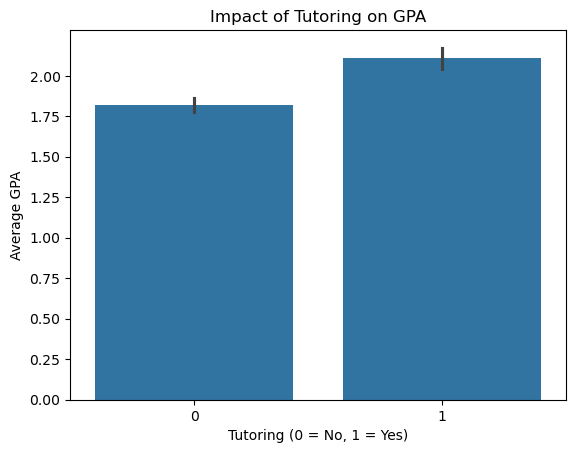

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.barplot(x='tutoring',y='gpa',data=df)
plt.title('Impact of Tutoring on GPA')
plt.xlabel('Tutoring (0 = No, 1 = Yes)')
plt.ylabel('Average GPA')
plt.yticks(np.arange(0, df['gpa'].mean() + 0.25, 0.25))
plt.show()

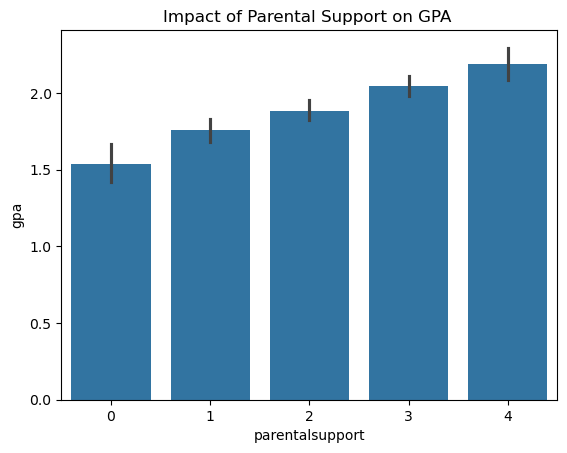

In [78]:
sns.barplot(x='parentalsupport',y='gpa',data=df)
plt.title('Impact of Parental Support on GPA ')
plt.show()

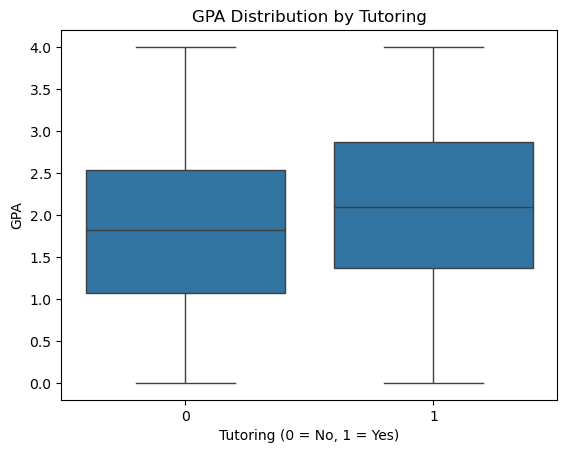

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.boxplot(x='tutoring',y='gpa',data=df)
plt.title('GPA Distribution by Tutoring')
plt.xlabel('Tutoring (0 = No, 1 = Yes)')
plt.ylabel('GPA')
plt.show()

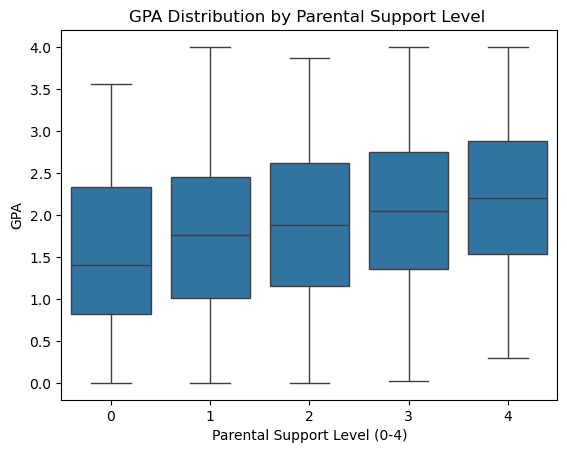

In [80]:
sns.boxplot(x='parentalsupport',y='gpa',data=df)
plt.title('GPA Distribution by Parental Support Level ')
plt.xlabel('Parental Support Level (0-4)')
plt.ylabel('GPA')
plt.show()

In [81]:
df[['gpa','tutoring','parentalsupport','studytimeweekly','absences']].corr()

,gpa,tutoring,parentalsupport,studytimeweekly,absences
gpa,1.000000,0.145119,0.190774,0.179275,-0.919314
tutoring,0.145119,1.000000,-0.000824,0.028930,-0.015534
parentalsupport,0.190774,-0.000824,1.000000,0.035800,0.002108
studytimeweekly,0.179275,0.028930,0.035800,1.000000,0.009326
absences,-0.919314,-0.015534,0.002108,0.009326,1.000000


Students receiving tutoring have an average GPA ~0.28 higher than those without tutoring.

Parental support shows a stronger and more consistent relationship with GPA than tutoring.

GPA increases progressively with higher parental support levels.

Absences show a negative correlation with GPA, indicating attendance is critical.

Study time has a moderate positive impact but is less influential than parental support.

In [82]:
X = df[['studytimeweekly']]
Y= df['gpa']

In [83]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,random_state=42)

In [84]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

In [85]:
slope = model.coef_[0]
intercept =model.intercept_

print('Slope:',slope)
print('Intercept:',intercept)

Slope: 0.03125081011912532
Intercept: 1.5964706415347973


In [86]:
from sklearn.metrics import r2_score, mean_squared_error
Y_pred = model.predict(X_test)

print('R^2:',r2_score(Y_test,Y_pred))
print('MSE:',mean_squared_error(Y_test,Y_pred))

R^2: 0.007480506788430263
MSE: 0.820746738998584


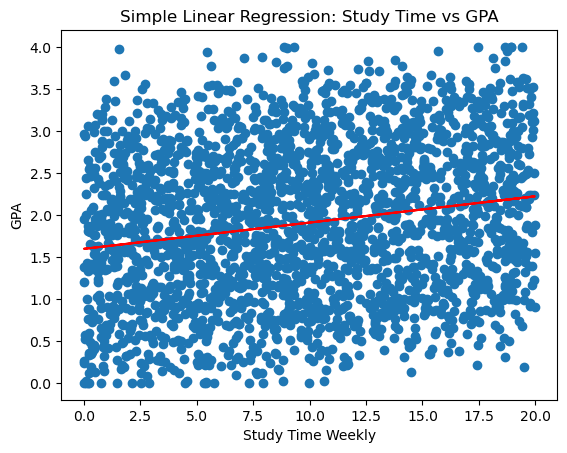

In [87]:
import matplotlib.pyplot as plt
plt.scatter(X,Y)
plt.plot(X, model.predict(X),color='red')
plt.xlabel('Study Time Weekly')
plt.ylabel('GPA')
plt.title('Simple Linear Regression: Study Time vs GPA')
plt.show()

A simple linear regression model was built to study the relationship between weekly study time and GPA.

The model shows a positive relationship, indicating that increased study time is associated with higher GPA.

However, the R² value suggests that study time alone explains less than 1% of the variation in GPA, implying that other factors such as parental support, absences, and tutoring play significant roles.

Study time has a positive but very weak relationship with GPA, suggesting that academic performance is influenced more by other factors than study time alone.

In [88]:
X = df[['absences']]
y = df['gpa']

In [89]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,random_state=42)

In [90]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

In [91]:
slope = model.coef_[0]
intercept =model.intercept_

print('Slope:',slope)
print('Intercept:',intercept)

Slope: -0.09925832981335495
Intercept: 3.352117366675971


In [92]:
from sklearn.metrics import r2_score, mean_squared_error
Y_pred = model.predict(X_test)

print('R^2:',r2_score(Y_test,Y_pred))
print('MSE:',mean_squared_error(Y_test,Y_pred))

R^2: 0.847774631744824
MSE: 0.12588012169314827


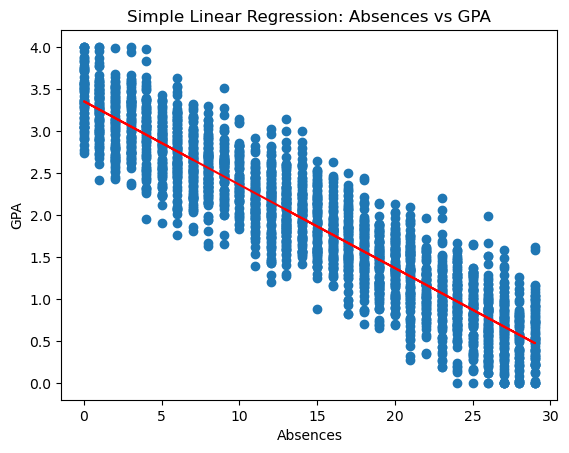

In [93]:
import matplotlib.pyplot as plt
plt.scatter(X,Y)
plt.plot(X, model.predict(X),color='red')
plt.xlabel('Absences')
plt.ylabel('GPA')
plt.title('Simple Linear Regression: Absences vs GPA')
plt.show()

The scatter plot shows a clear downward linear trend with relatively low dispersion around the regression line, indicating a strong negative linear relationship between absences and GPA.

**Key Findings:**

Absences are the strongest predictor of GPA, explaining approximately 84% of variance.

Study time shows a positive but weak relationship with GPA.

Parental Support has a stronger impact on academic performance than tutoring.

Behavioral factors (attendance) outweigh effort-based factors (study hours).

**Recommendations:**

School should prioritize attendance monitoring and intervention.

Parental engagement programs may yield better outcomes than tutoring alone.

Tutoring should be targeted rather than generalized. 